# Install and Import Libraries

In [ ]:
!pip install timm -q 
!pip install torchmetrics -q
!pip install matplotlib seaborn scikit-learn -q

In [3]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import timm

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


# Load & Explore Dataset

In [ ]:
DATASET_PATH = Path('/kaggle/input/datasets/ismailpromus/skin-diseases-image-dataset/IMG_CLASSES')

print('Dataset folders:')
for folder in sorted(DATASET_PATH.iterdir()):
    print(f'  {folder.name}')

Dataset folders:
  1. Eczema 1677
  10. Warts Molluscum and other Viral Infections - 2103
  2. Melanoma 15.75k
  3. Atopic Dermatitis - 1.25k
  4. Basal Cell Carcinoma (BCC) 3323
  5. Melanocytic Nevi (NV) - 7970
  6. Benign Keratosis-like Lesions (BKL) 2624
  7. Psoriasis pictures Lichen Planus and related diseases - 2k
  8. Seborrheic Keratoses and other Benign Tumors - 1.8k
  9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k


In [ ]:
TRAIN_DIR = DATASET_PATH

if not TRAIN_DIR.exists():
    TRAIN_DIR = DATASET_PATH
    print('No train/ folder found, using root dataset folder')

CLASS_NAMES = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
NUM_CLASSES = len(CLASS_NAMES)
print(f'\nNumber of classes: {NUM_CLASSES}')
print(f'Classes: {CLASS_NAMES}')


Number of classes: 10
Classes: ['1. Eczema 1677', '10. Warts Molluscum and other Viral Infections - 2103', '2. Melanoma 15.75k', '3. Atopic Dermatitis - 1.25k', '4. Basal Cell Carcinoma (BCC) 3323', '5. Melanocytic Nevi (NV) - 7970', '6. Benign Keratosis-like Lesions (BKL) 2624', '7. Psoriasis pictures Lichen Planus and related diseases - 2k', '8. Seborrheic Keratoses and other Benign Tumors - 1.8k', '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k']


In [ ]:
class_counts = {}
all_image_paths = []
all_labels = []

for idx, class_name in enumerate(CLASS_NAMES):
    class_dir = TRAIN_DIR / class_name
    images = list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.jpeg')) + list(class_dir.glob('*.png'))
    class_counts[class_name] = len(images)
    all_image_paths.extend(images)
    all_labels.extend([idx] * len(images))

print('Images per class:')
for cls, count in class_counts.items():
    print(f'  {cls}: {count} images')
print(f'\nTotal images: {len(all_image_paths)}')

Images per class:
  1. Eczema 1677: 1677 images
  10. Warts Molluscum and other Viral Infections - 2103: 2103 images
  2. Melanoma 15.75k: 3140 images
  3. Atopic Dermatitis - 1.25k: 1257 images
  4. Basal Cell Carcinoma (BCC) 3323: 3323 images
  5. Melanocytic Nevi (NV) - 7970: 7970 images
  6. Benign Keratosis-like Lesions (BKL) 2624: 2079 images
  7. Psoriasis pictures Lichen Planus and related diseases - 2k: 2055 images
  8. Seborrheic Keratoses and other Benign Tumors - 1.8k: 1847 images
  9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k: 1702 images

Total images: 27153


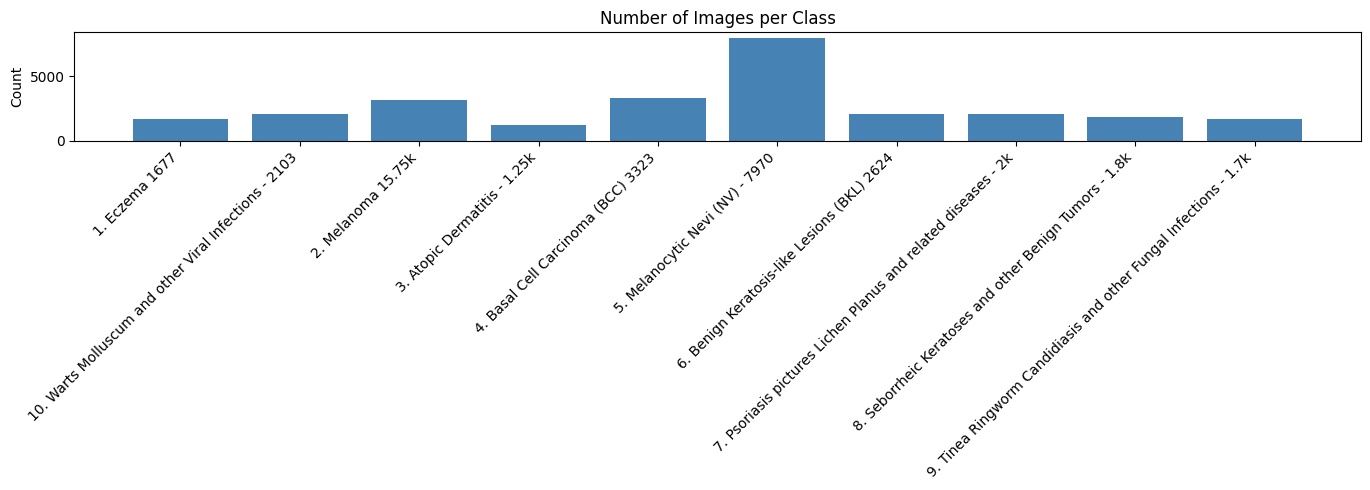

In [7]:
# Visualize class distribution
plt.figure(figsize=(14, 5))
plt.bar(class_counts.keys(), class_counts.values(), color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('Number of Images per Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

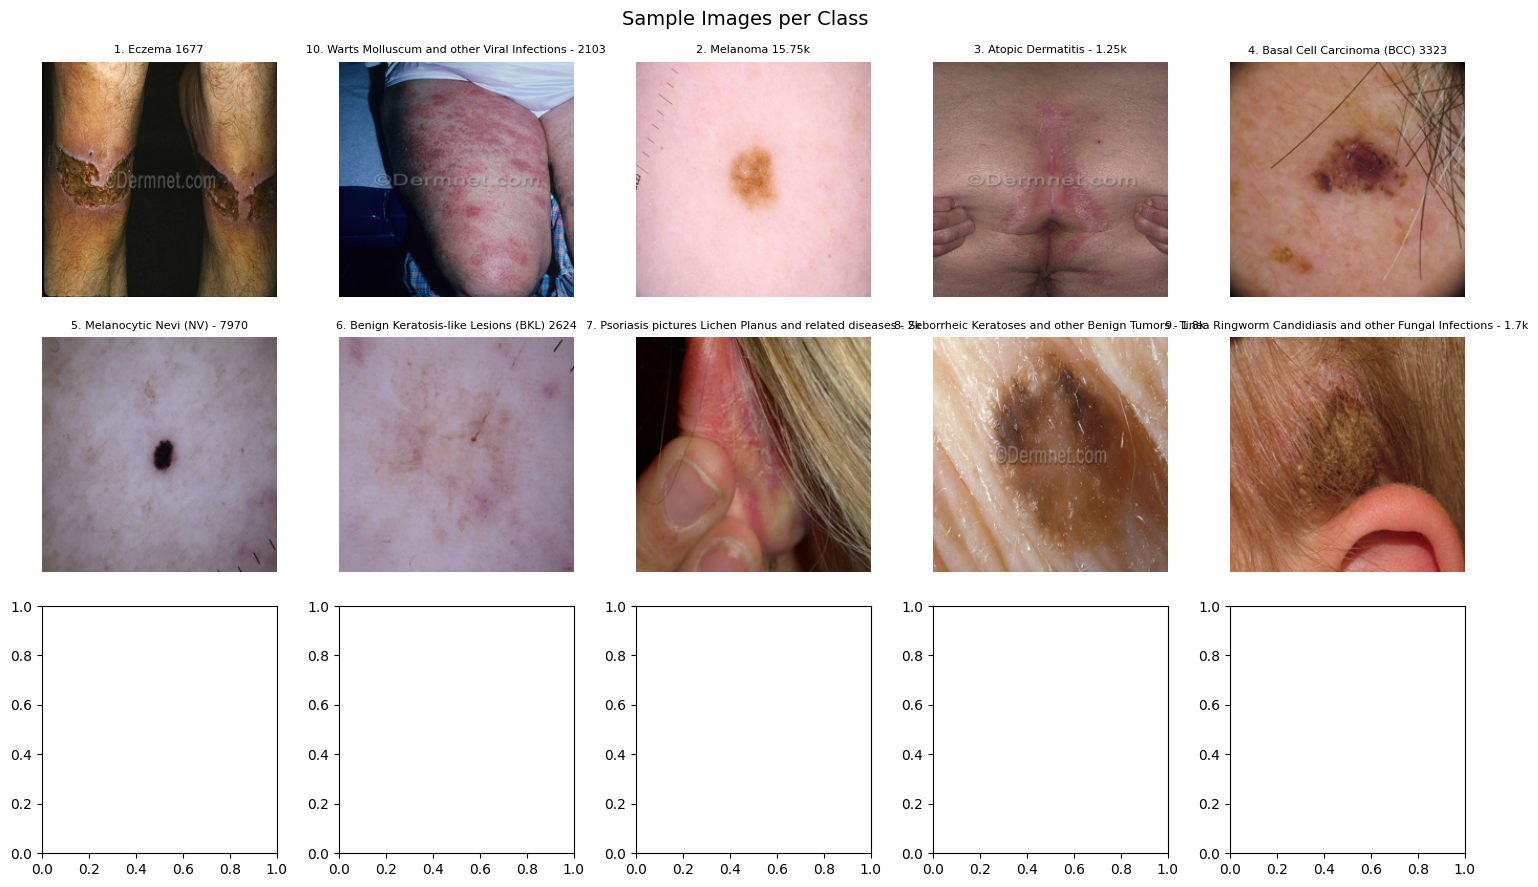

In [8]:
# Show sample images from each class
fig, axes = plt.subplots(3, min(NUM_CLASSES, 5), figsize=(15, 9))
axes = axes.flatten()

for idx, class_name in enumerate(CLASS_NAMES[:15]):
    class_dir = TRAIN_DIR / class_name
    sample_img_path = list(class_dir.glob('*.jpg'))[0]
    img = Image.open(sample_img_path).resize((224, 224))
    axes[idx].imshow(img)
    axes[idx].set_title(class_name, fontsize=8)
    axes[idx].axis('off')

plt.suptitle('Sample Images per Class', fontsize=14)
plt.tight_layout()
plt.show()

# Preprocess & Augment Images

In [ ]:
IMG_SIZE    = 224      
BATCH_SIZE  = 32       
NUM_EPOCHS  = 20       
LR          = 3e-4     
VAL_SPLIT   = 0.2     
SEED        = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

In [ ]:
# Train/Validation split
train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_image_paths, all_labels,
    test_size=VAL_SPLIT,
    stratify=all_labels,   
    random_state=SEED
)

print(f'Training samples:   {len(train_paths)}')
print(f'Validation samples: {len(val_paths)}')

Training samples:   21722
Validation samples: 5431


In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),           
    transforms.RandomCrop(224),              
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),          
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.1),       
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),           
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print('Transforms defined!')

Transforms defined!


In [ ]:
class SkinDiseaseDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label


train_dataset = SkinDiseaseDataset(train_paths, train_labels, transform=train_transforms)
val_dataset   = SkinDiseaseDataset(val_paths,   val_labels,   transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')

Train batches: 679
Val batches:   170


# Build the Model (EfficientNet-B0)

In [ ]:
model = timm.create_model(
    'efficientnet_b0',
    pretrained=True,      
    num_classes=NUM_CLASSES 
)

model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Total parameters:     4,020,358
Trainable parameters: 4,020,358


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print('Class weights (higher = model pays more attention):')
for name, weight in zip(CLASS_NAMES, class_weights):
    print(f'  {weight:.3f} - {name}')

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

print('\nModel, optimizer, and scheduler ready!')

Class weights (higher = model pays more attention):
  1.619 - 1. Eczema 1677
  1.291 - 10. Warts Molluscum and other Viral Infections - 2103
  0.865 - 2. Melanoma 15.75k
  2.159 - 3. Atopic Dermatitis - 1.25k
  0.817 - 4. Basal Cell Carcinoma (BCC) 3323
  0.341 - 5. Melanocytic Nevi (NV) - 7970
  1.306 - 6. Benign Keratosis-like Lesions (BKL) 2624
  1.321 - 7. Psoriasis pictures Lichen Planus and related diseases - 2k
  1.471 - 8. Seborrheic Keratoses and other Benign Tumors - 1.8k
  1.595 - 9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k

Model, optimizer, and scheduler ready!


# Train the Model

In [15]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for batch_idx, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

        if (batch_idx + 1) % 20 == 0:
            print(f'  Batch [{batch_idx+1}/{len(loader)}] '
                  f'Loss: {running_loss/(batch_idx+1):.4f} '
                  f'Acc: {100.*correct/total:.2f}%')

    epoch_loss = running_loss / len(loader)
    epoch_acc  = 100. * correct / total
    return epoch_loss, epoch_acc


def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / len(loader)
    val_acc  = 100. * correct / total
    return val_loss, val_acc


print('Training functions defined!')

Training functions defined!


In [ ]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
SAVE_PATH = '/kaggle/working/best_model.pt'

print('Starting training...\n')

for epoch in range(1, NUM_EPOCHS + 1):
    print(f'Epoch [{epoch}/{NUM_EPOCHS}]')

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc     = validate(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%')
    print(f'  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.2f}%')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'class_names': CLASS_NAMES,
            'num_classes': NUM_CLASSES
        }, SAVE_PATH)
        print(f'  ✅ Best model saved! Val Acc: {val_acc:.2f}%')

    print()

print(f'Training complete! Best Val Accuracy: {best_val_acc:.2f}%')

Starting training...

Epoch [1/20]
  Batch [20/679] Loss: 2.8817 Acc: 27.34%
  Batch [40/679] Loss: 2.4064 Acc: 34.92%
  Batch [60/679] Loss: 2.2158 Acc: 38.12%
  Batch [80/679] Loss: 2.0654 Acc: 41.09%
  Batch [100/679] Loss: 1.9518 Acc: 43.22%
  Batch [120/679] Loss: 1.8906 Acc: 44.14%
  Batch [140/679] Loss: 1.8399 Acc: 44.98%
  Batch [160/679] Loss: 1.7785 Acc: 46.29%
  Batch [180/679] Loss: 1.7367 Acc: 47.12%
  Batch [200/679] Loss: 1.6945 Acc: 48.03%
  Batch [220/679] Loss: 1.6645 Acc: 48.54%
  Batch [240/679] Loss: 1.6311 Acc: 49.14%
  Batch [260/679] Loss: 1.6096 Acc: 49.53%
  Batch [280/679] Loss: 1.5841 Acc: 50.00%
  Batch [300/679] Loss: 1.5636 Acc: 50.43%
  Batch [320/679] Loss: 1.5444 Acc: 50.86%
  Batch [340/679] Loss: 1.5201 Acc: 51.36%
  Batch [360/679] Loss: 1.5006 Acc: 51.94%
  Batch [380/679] Loss: 1.4872 Acc: 52.18%
  Batch [400/679] Loss: 1.4723 Acc: 52.54%
  Batch [420/679] Loss: 1.4573 Acc: 53.07%
  Batch [440/679] Loss: 1.4431 Acc: 53.39%
  Batch [460/679] Loss:

# Evalutate the Model

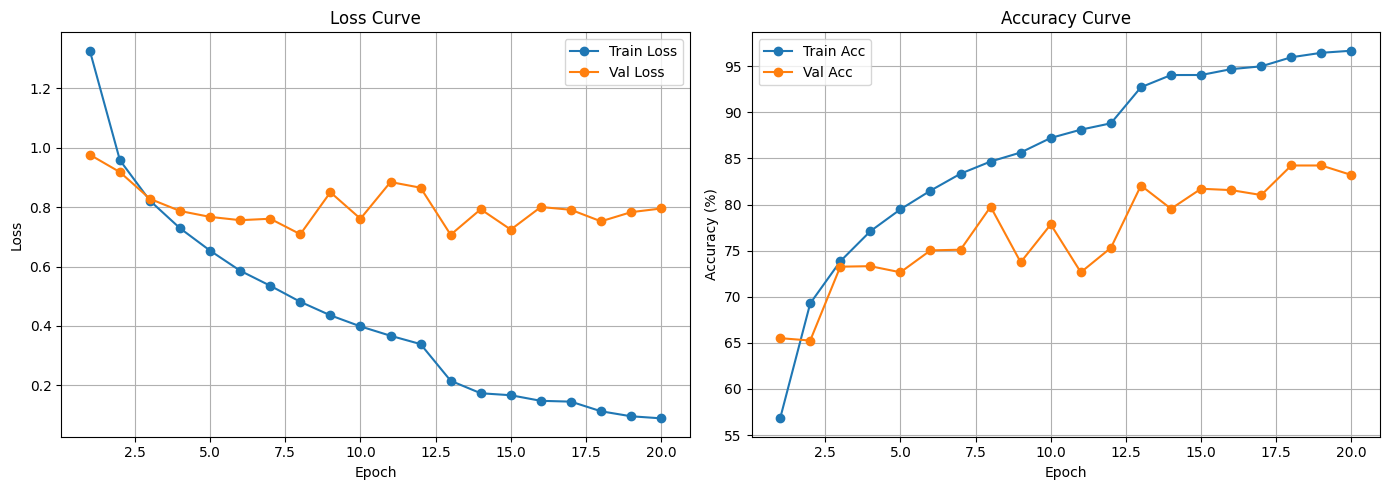

In [17]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, NUM_EPOCHS + 1)

ax1.plot(epochs_range, history['train_loss'], label='Train Loss', marker='o')
ax1.plot(epochs_range, history['val_loss'],   label='Val Loss',   marker='o')
ax1.set_title('Loss Curve')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs_range, history['train_acc'], label='Train Acc', marker='o')
ax2.plot(epochs_range, history['val_acc'],   label='Val Acc',   marker='o')
ax2.set_title('Accuracy Curve')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

In [ ]:
checkpoint = torch.load(SAVE_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f'Loaded best model from epoch {checkpoint["epoch"]} with Val Acc: {checkpoint["val_acc"]:.2f}%')

Loaded best model from epoch 18 with Val Acc: 84.24%


In [ ]:
model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_true.extend(labels.numpy())

print('Classification Report:')
print(classification_report(all_true, all_preds, target_names=CLASS_NAMES))

Classification Report:
                                                                  precision    recall  f1-score   support

                                                  1. Eczema 1677       0.75      0.74      0.75       335
           10. Warts Molluscum and other Viral Infections - 2103       0.79      0.76      0.78       421
                                              2. Melanoma 15.75k       0.78      0.98      0.87       628
                                    3. Atopic Dermatitis - 1.25k       0.60      0.75      0.66       251
                              4. Basal Cell Carcinoma (BCC) 3323       0.92      0.95      0.93       665
                                 5. Melanocytic Nevi (NV) - 7970       0.97      0.87      0.92      1594
                     6. Benign Keratosis-like Lesions (BKL) 2624       0.85      0.84      0.85       416
   7. Psoriasis pictures Lichen Planus and related diseases - 2k       0.70      0.69      0.69       411
          8. Seborrhei

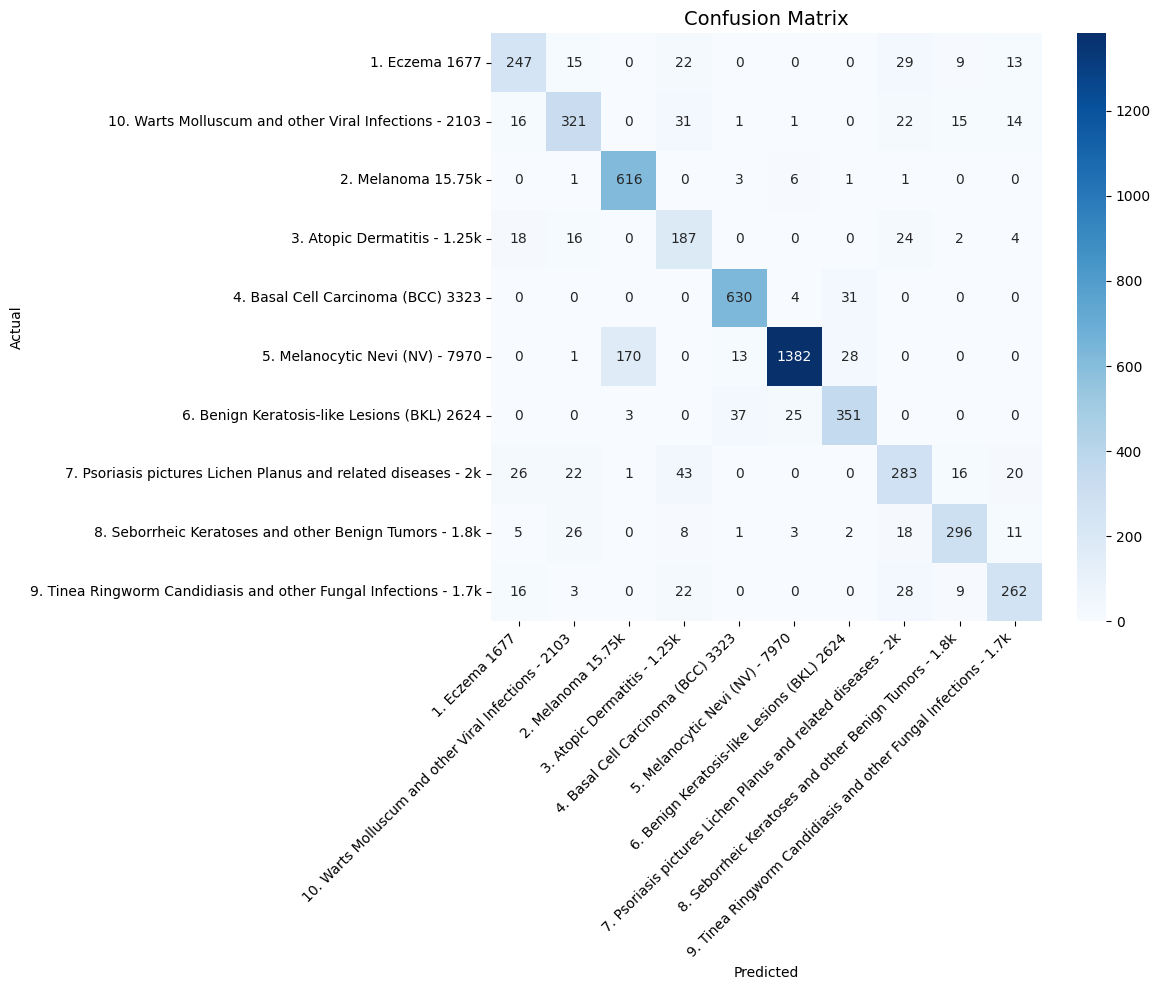

In [ ]:
cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()

In [21]:
import json

class_info = {
    'class_names': CLASS_NAMES,
    'num_classes': NUM_CLASSES
}

with open('/kaggle/working/class_names.json', 'w') as f:
    json.dump(class_info, f, indent=2)

print('Saved! Classes:')
for i, name in enumerate(CLASS_NAMES):
    print(f'  {i}: {name}')

Saved! Classes:
  0: 1. Eczema 1677
  1: 10. Warts Molluscum and other Viral Infections - 2103
  2: 2. Melanoma 15.75k
  3: 3. Atopic Dermatitis - 1.25k
  4: 4. Basal Cell Carcinoma (BCC) 3323
  5: 5. Melanocytic Nevi (NV) - 7970
  6: 6. Benign Keratosis-like Lesions (BKL) 2624
  7: 7. Psoriasis pictures Lichen Planus and related diseases - 2k
  8: 8. Seborrheic Keratoses and other Benign Tumors - 1.8k
  9: 9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k


In [ ]:
import json

clean_names = {
    '1. Eczema 1677': 'Eczema',
    '10. Warts Molluscum and other Viral Infections - 2103': 'Warts & Viral Infections',
    '2. Melanoma 15.75k': 'Melanoma',
    '3. Atopic Dermatitis - 1.25k': 'Atopic Dermatitis',
    '4. Basal Cell Carcinoma (BCC) 3323': 'Basal Cell Carcinoma',
    '5. Melanocytic Nevi (NV) - 7970': 'Melanocytic Nevi',
    '6. Benign Keratosis-like Lesions (BKL) 2624': 'Benign Keratosis',
    '7. Psoriasis pictures Lichen Planus and related diseases - 2k': 'Psoriasis & Lichen Planus',
    '8. Seborrheic Keratoses and other Benign Tumors - 1.8k': 'Seborrheic Keratoses',
    '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k': 'Tinea & Fungal Infections'
}

class_info = {
    'class_names': CLASS_NAMES,         
    'clean_names': clean_names,          
    'num_classes': NUM_CLASSES
}

with open('/kaggle/working/class_names.json', 'w') as f:
    json.dump(class_info, f, indent=2)

print('✅ class_names.json updated with clean names!')
print('\nClean class names:')
for raw, clean in clean_names.items():
    print(f'  {clean}')

✅ class_names.json updated with clean names!

Clean class names:
  Eczema
  Warts & Viral Infections
  Melanoma
  Atopic Dermatitis
  Basal Cell Carcinoma
  Melanocytic Nevi
  Benign Keratosis
  Psoriasis & Lichen Planus
  Seborrheic Keratoses
  Tinea & Fungal Infections
